# **Segment-Level Advertising Incrementality Analysis**

## **Objective**

This notebook investigates whether the incremental effect of advertising assignment differs across anonymized user-feature segments in the Criteo Uplift Prediction Dataset.

The analysis:

- Reviews the distributions and cardinality of anonymized features `f0` through `f11`.
- Creates data-driven segments for features that can form sufficiently distinct groups.
- Estimates treatment and control conversion rates within each segment.
- Calculates absolute and relative conversion-rate lift and 95% confidence intervals.
- Applies multiple-testing correction to the within-segment and feature-level tests.
- Tests whether treatment odds ratios vary across the bins of each retained feature.
- Flags exploratory follow-up candidates for a new randomized experiment.

The anonymized features cannot be translated directly into operational targeting rules. The feature-level heterogeneity test is on the odds-ratio scale; candidate ranking uses absolute rate lift only as a descriptive measure.


## **Imports**

`pandas` and `numpy` support data preparation, `matplotlib` produces the visualization, and `statsmodels` provides proportion tests, confidence intervals, multiple-testing correction, and stratified contingency-table analysis.


In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from statsmodels.stats.contingency_tables import StratifiedTable
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportions_ztest,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")


## **Data Loading**

The analysis loads the anonymized user features `f0`–`f11`, randomized `treatment` assignment, and binary `conversion` outcome. It uses an intention-to-treat framework; `exposure` and `visit` are therefore not required here.


In [17]:
file_path = Path("../data/raw/criteo-uplift-v2.1.csv.gz")

feature_columns = [f"f{i}" for i in range(12)]
analysis_columns = feature_columns + ["treatment", "conversion"]

df = pd.read_csv(file_path, usecols=analysis_columns)

print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (13979592, 14)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0
3,12.616365,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0
4,12.616365,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0


In [18]:
data_loading_checks = {
    "Total observations": len(df),
    "Total columns": df.shape[1],
    "Missing values": int(df.isna().sum().sum()),
    "Invalid treatment values": int((~df["treatment"].isin([0, 1])).sum()),
    "Invalid conversion values": int((~df["conversion"].isin([0, 1])).sum()),
}

data_loading_checks


{'Total observations': 13979592,
 'Total columns': 14,
 'Missing values': 0,
 'Invalid treatment values': 0,
 'Invalid conversion values': 0}

### **Data Loading Validation**

The checks confirm that the analysis dataset contains the expected variables and valid binary experiment fields. Any nonzero missing-value or invalid-value result should be investigated before continuing.


## **Feature Overview**

Before constructing segments, the features are reviewed for missing values, cardinality, distribution, quartile boundaries, and the number of distinct quantile-based bins they can potentially form. Repeated values can cause multiple quartile boundaries to coincide.


In [19]:
feature_summary = df[feature_columns].describe().T
feature_summary["missing_values"] = df[feature_columns].isna().sum()
feature_summary["unique_values"] = df[feature_columns].nunique()

feature_summary = feature_summary[
    [
        "count", "missing_values", "unique_values", "mean", "std",
        "min", "25%", "50%", "75%", "max",
    ]
]

display(feature_summary)


,count,missing_values,unique_values,mean,std,min,25%,50%,75%,max
f0,"13,979,592.000000",0,2181959,19.620297,5.377464,12.616365,12.616365,21.923413,24.436459,26.745255
f1,"13,979,592.000000",0,60,10.069977,0.104756,10.059654,10.059654,10.059654,10.059654,16.344187
f2,"13,979,592.000000",0,2051900,8.446582,0.299316,8.214383,8.214383,8.214383,8.723335,9.051962
f3,"13,979,592.000000",0,552,4.178923,1.336645,-8.398387,4.679882,4.679882,4.679882,4.679882
f4,"13,979,592.000000",0,260,10.338837,0.343308,10.280525,10.280525,10.280525,10.280525,21.123508
f5,"13,979,592.000000",0,132,4.028513,0.431097,-9.011892,4.115453,4.115453,4.115453,4.115453
f6,"13,979,592.000000",0,1645,-4.155356,4.577914,-31.429784,-6.699321,-2.411115,0.294443,0.294443
f7,"13,979,592.000000",0,622143,5.101765,1.205248,4.833815,4.833815,4.833815,4.833815,11.998401
f8,"13,979,592.000000",0,3743,3.933581,0.056660,3.635107,3.910792,3.971858,3.971858,3.971858
f9,"13,979,592.000000",0,1594,16.027638,7.018975,13.190056,13.190056,13.190056,13.190056,75.295017


In [20]:
quantile_probabilities = [0, 0.25, 0.50, 0.75, 1]
feature_overview_records = []

for feature in feature_columns:
    quantile_edges = (
        df[feature]
        .quantile(quantile_probabilities)
        .drop_duplicates()
    )

    feature_overview_records.append({
        "feature": feature,
        "unique_values": df[feature].nunique(),
        "distinct_quantile_edges": len(quantile_edges),
        "possible_quantile_bins": max(len(quantile_edges) - 1, 0),
    })

feature_overview = pd.DataFrame(feature_overview_records)
display(feature_overview)


,feature,unique_values,distinct_quantile_edges,possible_quantile_bins
0,f0,2181959,4,3
1,f1,60,2,1
2,f2,2051900,3,2
3,f3,552,2,1
4,f4,260,2,1
5,f5,132,2,1
6,f6,1645,4,3
7,f7,622143,2,1
8,f8,3743,3,2
9,f9,1594,2,1


### **Feature Overview Interpretation**

A high number of unique values does not guarantee four distinct quantile groups. Segment eligibility is therefore based on the groups actually produced by quantile segmentation. Features unable to form at least two groups are excluded.


## **Feature Segmentation**

Each feature is divided into a maximum of four quantile-based segments using `pd.qcut()`. Duplicate boundaries are removed automatically. Labels use `Bin 1`, `Bin 2`, and so forth because some features cannot form four complete quartiles.


In [21]:
segment_columns = []
segmentation_summary_records = []
segment_definition_records = []

for feature in feature_columns:
    segment_column = f"{feature}_segment"

    try:
        quantile_segments = pd.qcut(
            df[feature],
            q=4,
            duplicates="drop",
            precision=6,
        )
        number_of_segments = len(quantile_segments.cat.categories)

        if number_of_segments < 2:
            segmentation_summary_records.append({
                "feature": feature,
                "segments_created": number_of_segments,
                "status": "Excluded",
            })
            continue

        segment_labels = [
            f"Bin {number}"
            for number in range(1, number_of_segments + 1)
        ]

        df[segment_column] = quantile_segments.cat.rename_categories(
            segment_labels
        )
        segment_columns.append(segment_column)

        segmentation_summary_records.append({
            "feature": feature,
            "segments_created": number_of_segments,
            "status": "Included",
        })

        segment_counts = df[segment_column].value_counts(sort=False)

        for label, interval in zip(
            segment_labels,
            quantile_segments.cat.categories,
        ):
            segment_definition_records.append({
                "feature": feature,
                "segment": label,
                "lower_bound": interval.left,
                "upper_bound": interval.right,
                "observations": int(segment_counts.get(label, 0)),
            })

    except ValueError as error:
        segmentation_summary_records.append({
            "feature": feature,
            "segments_created": 0,
            "status": "Excluded",
        })
        print(f"{feature}: excluded — {error}")

segmentation_summary = pd.DataFrame(segmentation_summary_records)
segment_definitions = pd.DataFrame(segment_definition_records)

display(segmentation_summary)
display(segment_definitions)

print("Segment columns included in the analysis:")
for segment_column in segment_columns:
    print(f"- {segment_column}")


,feature,segments_created,status
0,f0,3,Included
1,f1,1,Excluded
2,f2,2,Included
3,f3,1,Excluded
4,f4,1,Excluded
5,f5,1,Excluded
6,f6,3,Included
7,f7,1,Excluded
8,f8,2,Included
9,f9,1,Excluded


,feature,segment,lower_bound,upper_bound,observations
0,f0,Bin 1,12.616364,21.923413,6989796
1,f0,Bin 2,21.923413,24.436459,3494900
2,f0,Bin 3,24.436459,26.745255,3494896
3,f2,Bin 1,8.214382,8.723335,10484694
4,f2,Bin 2,8.723335,9.051962,3494898
5,f6,Bin 1,-31.429785,-6.699321,3622644
6,f6,Bin 2,-6.699321,-2.411115,4418921
7,f6,Bin 3,-2.411115,0.294443,5938027
8,f8,Bin 1,3.635106,3.910792,3539789
9,f8,Bin 2,3.910792,3.971858,10439803


Segment columns included in the analysis:
- f0_segment
- f2_segment
- f6_segment
- f8_segment


### **Segmentation Interpretation**

Each feature is segmented independently, so segments from different features overlap. The same observation can belong to one bin for every retained feature. Consequently, incremental conversions must not be added across different features.


## Segment-Level Treatment Effects

For each segment, the analysis calculates group sizes, conversions, rates, absolute and relative lift, and estimated incremental conversions.

$$
\text{Absolute Lift}
= \text{Treatment Rate} - \text{Control Rate}
$$

$$
\text{Relative Lift}
= \frac{\text{Absolute Lift}}{\text{Control Rate}}
$$

$$
\text{Estimated Incremental Conversions}
= \text{Absolute Lift} \times \text{Treatment Users}
$$


In [22]:
segment_result_records = []

for segment_column in segment_columns:
    feature_name = segment_column.replace("_segment", "")

    for segment in df[segment_column].cat.categories:
        segment_mask = df[segment_column] == segment
        control_mask = segment_mask & (df["treatment"] == 0)
        treatment_mask = segment_mask & (df["treatment"] == 1)

        control_users = int(control_mask.sum())
        treatment_users = int(treatment_mask.sum())

        if control_users == 0 or treatment_users == 0:
            continue

        control_conversions = int(df.loc[control_mask, "conversion"].sum())
        treatment_conversions = int(
            df.loc[treatment_mask, "conversion"].sum()
        )

        control_rate = control_conversions / control_users
        treatment_rate = treatment_conversions / treatment_users
        absolute_lift = treatment_rate - control_rate
        relative_lift = (
            absolute_lift / control_rate
            if control_rate > 0
            else np.nan
        )

        segment_result_records.append({
            "feature": feature_name,
            "segment": str(segment),
            "segment_label": f"{feature_name} - {segment}",
            "control_users": control_users,
            "treatment_users": treatment_users,
            "treatment_allocation_rate": (
                treatment_users / (control_users + treatment_users)
            ),
            "control_conversions": control_conversions,
            "treatment_conversions": treatment_conversions,
            "control_rate": control_rate,
            "treatment_rate": treatment_rate,
            "absolute_lift": absolute_lift,
            "relative_lift": relative_lift,
            "incremental_conversions": absolute_lift * treatment_users,
        })

segment_results = (
    pd.DataFrame(segment_result_records)
    .sort_values(["feature", "segment"])
    .reset_index(drop=True)
)

print(f"Segment-level comparisons created: {len(segment_results)}")
display(segment_results)


Segment-level comparisons created: 10


,feature,segment,segment_label,control_users,treatment_users,treatment_allocation_rate,control_conversions,treatment_conversions,control_rate,treatment_rate,absolute_lift,relative_lift,incremental_conversions
0,f0,Bin 1,f0 - Bin 1,1040133,5949663,0.851193,3558,32999,0.003421,0.005546,0.002126,0.621404,"12,646.890266"
1,f0,Bin 2,f0 - Bin 2,526737,2968163,0.849284,321,2384,0.000609,0.000803,0.000194,0.317975,575.164997
2,f0,Bin 3,f0 - Bin 3,530067,2964829,0.848331,184,1328,0.000347,0.000448,0.000101,0.290361,298.830978
3,f2,Bin 1,f2 - Bin 1,1566234,8918460,0.850617,3810,34384,0.002433,0.003855,0.001423,0.584887,"12,689.072805"
4,f2,Bin 2,f2 - Bin 2,530703,2964195,0.848149,253,2327,0.000477,0.000785,0.000308,0.646723,913.890719
5,f6,Bin 1,f6 - Bin 1,520347,3102297,0.856363,2450,24872,0.004708,0.008017,0.003309,0.702763,"10,265.155625"
6,f6,Bin 2,f6 - Bin 2,666412,3752509,0.849191,599,4793,0.000899,0.001277,0.000378,0.421025,"1,420.082209"
7,f6,Bin 3,f6 - Bin 3,910178,5027849,0.846720,1014,7046,0.001114,0.001401,0.000287,0.257908,"1,444.635337"
8,f8,Bin 1,f8 - Bin 1,516554,3023235,0.854072,3851,34761,0.007455,0.011498,0.004043,0.542278,"12,222.256742"
9,f8,Bin 2,f8 - Bin 2,1580383,8859420,0.848619,212,1950,0.000134,0.000220,0.000086,0.640801,761.555781


### **Treatment-Effect Interpretation**

A positive lift means treatment users converted at a higher rate within that segment. At this stage, the differences are descriptive. A significant effect within a segment does not prove that its effect differs from another segment's effect.


## **Statistical Significance Testing and Confidence Intervals**

A two-sided two-sample proportion z-test evaluates whether treatment and control conversion rates differ within each segment. A 95% confidence interval is calculated for treatment rate minus control rate. These initial p-values are subsequently corrected for multiple testing.


In [23]:
z_statistics = []
p_values = []
ci_lower_values = []
ci_upper_values = []

for _, row in segment_results.iterrows():
    successes = np.array([
        row["treatment_conversions"],
        row["control_conversions"],
    ])
    observations = np.array([
        row["treatment_users"],
        row["control_users"],
    ])

    z_statistic, p_value = proportions_ztest(
        count=successes,
        nobs=observations,
        alternative="two-sided",
    )

    ci_lower, ci_upper = confint_proportions_2indep(
        count1=int(row["treatment_conversions"]),
        nobs1=int(row["treatment_users"]),
        count2=int(row["control_conversions"]),
        nobs2=int(row["control_users"]),
        method="wald",
        compare="diff",
        alpha=0.05,
    )

    z_statistics.append(z_statistic)
    p_values.append(p_value)
    ci_lower_values.append(ci_lower)
    ci_upper_values.append(ci_upper)

segment_results["z_statistic"] = z_statistics
segment_results["p_value"] = p_values
segment_results["ci_lower"] = ci_lower_values
segment_results["ci_upper"] = ci_upper_values
segment_results["significant_unadjusted"] = segment_results["p_value"] < 0.05
segment_results["ci_excludes_zero"] = (
    (segment_results["ci_lower"] > 0)
    | (segment_results["ci_upper"] < 0)
)

display(
    segment_results[
        [
            "segment_label", "control_rate", "treatment_rate",
            "absolute_lift", "ci_lower", "ci_upper", "z_statistic",
            "p_value", "significant_unadjusted",
        ]
    ]
)


,segment_label,control_rate,treatment_rate,absolute_lift,ci_lower,ci_upper,z_statistic,p_value,significant_unadjusted
0,f0 - Bin 1,0.003421,0.005546,0.002126,0.001999,0.002253,27.729076,0.000000,True
1,f0 - Bin 2,0.000609,0.000803,0.000194,0.000120,0.000268,4.660473,0.000003,True
2,f0 - Bin 3,0.000347,0.000448,0.000101,0.000045,0.000156,3.250194,0.001153,True
3,f2 - Bin 1,0.002433,0.003855,0.001423,0.001336,0.001510,27.258891,0.000000,True
4,f2 - Bin 2,0.000477,0.000785,0.000308,0.000241,0.000375,7.615829,0.000000,True
5,f6 - Bin 1,0.004708,0.008017,0.003309,0.003098,0.003520,25.530426,0.000000,True
6,f6 - Bin 2,0.000899,0.001277,0.000378,0.000298,0.000459,8.154817,0.000000,True
7,f6 - Bin 3,0.001114,0.001401,0.000287,0.000211,0.000363,6.851059,0.000000,True
8,f8 - Bin 1,0.007455,0.011498,0.004043,0.003779,0.004306,25.851980,0.000000,True
9,f8 - Bin 2,0.000134,0.000220,0.000086,0.000065,0.000106,6.918268,0.000000,True


## **Multiple-Testing Correction**

The Benjamini–Hochberg procedure controls the expected false discovery rate across all segment-level tests. It adjusts evidence that each segment's effect differs from zero; it does not test whether segments have different effects from one another.


In [24]:
fdr_alpha = 0.05

(
    significant_after_fdr,
    adjusted_p_values,
    _,
    _,
) = multipletests(
    segment_results["p_value"],
    alpha=fdr_alpha,
    method="fdr_bh",
)

segment_results["adjusted_p_value"] = adjusted_p_values
segment_results["significant_after_fdr"] = significant_after_fdr
segment_results["effect_direction"] = np.select(
    [
        segment_results["absolute_lift"] > 0,
        segment_results["absolute_lift"] < 0,
    ],
    ["Positive", "Negative"],
    default="No Difference",
)

print(f"Total segment-level tests: {len(segment_results)}")
print(
    "Significant before FDR correction: "
    f"{int(segment_results['significant_unadjusted'].sum())}"
)
print(
    "Significant after FDR correction: "
    f"{int(segment_results['significant_after_fdr'].sum())}"
)

display(
    segment_results[
        [
            "segment_label", "absolute_lift", "ci_lower", "ci_upper",
            "p_value", "adjusted_p_value", "significant_after_fdr",
            "effect_direction",
        ]
    ].sort_values("absolute_lift", ascending=False)
)


Total segment-level tests: 10
Significant before FDR correction: 10
Significant after FDR correction: 10


,segment_label,absolute_lift,ci_lower,ci_upper,p_value,adjusted_p_value,significant_after_fdr,effect_direction
8,f8 - Bin 1,0.004043,0.003779,0.004306,0.000000,0.000000,True,Positive
5,f6 - Bin 1,0.003309,0.003098,0.003520,0.000000,0.000000,True,Positive
0,f0 - Bin 1,0.002126,0.001999,0.002253,0.000000,0.000000,True,Positive
3,f2 - Bin 1,0.001423,0.001336,0.001510,0.000000,0.000000,True,Positive
6,f6 - Bin 2,0.000378,0.000298,0.000459,0.000000,0.000000,True,Positive
4,f2 - Bin 2,0.000308,0.000241,0.000375,0.000000,0.000000,True,Positive
7,f6 - Bin 3,0.000287,0.000211,0.000363,0.000000,0.000000,True,Positive
1,f0 - Bin 2,0.000194,0.000120,0.000268,0.000003,0.000004,True,Positive
2,f0 - Bin 3,0.000101,0.000045,0.000156,0.001153,0.001153,True,Positive
9,f8 - Bin 2,0.000086,0.000065,0.000106,0.000000,0.000000,True,Positive


## **Treatment-Effect Heterogeneity Testing**

Segment-level significance does not establish that effects differ across segments. For each feature, a Breslow–Day test compares the treatment-control odds ratios across its bins using aggregated 2×2 contingency tables.

The null hypothesis is that the treatment odds ratio is homogeneous across the feature's bins. A small p-value provides evidence that at least one bin has a different treatment effect on the odds-ratio scale. The summary tables retain absolute rate lift for business interpretation.


In [25]:
heterogeneity_records = []

for segment_column in segment_columns:
    feature_name = segment_column.replace("_segment", "")

    aggregated_data = (
        df.groupby([segment_column, "treatment"], observed=True)
        .agg(
            conversions=("conversion", "sum"),
            observations=("conversion", "size"),
        )
        .reset_index()
    )
    aggregated_data["non_conversions"] = (
        aggregated_data["observations"]
        - aggregated_data["conversions"]
    )
    aggregated_data["segment"] = aggregated_data[segment_column].astype(str)

    tables = []

    for segment in aggregated_data["segment"].unique():
        segment_table = (
            aggregated_data.loc[
                aggregated_data["segment"] == segment
            ]
            .set_index("treatment")
        )

        tables.append(np.array([
            [
                segment_table.loc[1, "conversions"],
                segment_table.loc[1, "non_conversions"],
            ],
            [
                segment_table.loc[0, "conversions"],
                segment_table.loc[0, "non_conversions"],
            ],
        ], dtype=float))

    stratified_table = StratifiedTable(
        np.stack(tables, axis=2),
        shift_zeros=True,
    )
    heterogeneity_test = stratified_table.test_equal_odds()
    heterogeneity_statistic = float(heterogeneity_test.statistic)
    heterogeneity_p_value = float(heterogeneity_test.pvalue)
    degrees_of_freedom = len(tables) - 1

    heterogeneity_records.append({
        "feature": feature_name,
        "segments_tested": aggregated_data["segment"].nunique(),
        "heterogeneity_statistic": heterogeneity_statistic,
        "degrees_of_freedom": degrees_of_freedom,
        "heterogeneity_p_value": heterogeneity_p_value,
        "heterogeneity_unadjusted": heterogeneity_p_value < 0.05,
    })

heterogeneity_results = (
    pd.DataFrame(heterogeneity_records)
    .sort_values("heterogeneity_p_value")
    .reset_index(drop=True)
)

(
    heterogeneity_significant_after_fdr,
    heterogeneity_adjusted_p_values,
    _,
    _,
) = multipletests(
    heterogeneity_results["heterogeneity_p_value"],
    alpha=0.05,
    method="fdr_bh",
)

heterogeneity_results["heterogeneity_adjusted_p_value"] = (
    heterogeneity_adjusted_p_values
)
heterogeneity_results["heterogeneity_after_fdr"] = (
    heterogeneity_significant_after_fdr
)

display(heterogeneity_results)


,feature,segments_tested,heterogeneity_statistic,degrees_of_freedom,heterogeneity_p_value,heterogeneity_unadjusted,heterogeneity_adjusted_p_value,heterogeneity_after_fdr
0,f6,3,63.768099,2,0.000000,True,0.000000,True
1,f0,3,18.459095,2,0.000098,True,0.000196,True
2,f8,2,0.607941,1,0.435564,False,0.580752,False
3,f2,2,0.295222,1,0.586894,False,0.586894,False


### **Heterogeneity-Test Interpretation**

An FDR-adjusted heterogeneity p-value below 0.05 indicates that at least one segment's treatment odds ratio differs within that feature. It does not identify which pair differs. A feature may contain several significant positive segment effects without significant heterogeneity, meaning advertising works in those bins but differential targeting is not yet supported.


## **Segment Results Summary**

The complete analytical table combines segment sizes, treatment effects, confidence intervals, corrected segment-level evidence, and corrected feature-level heterogeneity evidence.


In [26]:
heterogeneity_columns = [
    "feature",
    "heterogeneity_p_value",
    "heterogeneity_adjusted_p_value",
    "heterogeneity_after_fdr",
]

segment_results_summary = segment_results.merge(
    heterogeneity_results[heterogeneity_columns],
    on="feature",
    how="left",
    validate="many_to_one",
)

segment_results_summary["absolute_lift_percentage_points"] = (
    segment_results_summary["absolute_lift"] * 100
)
segment_results_summary["ci_lower_percentage_points"] = (
    segment_results_summary["ci_lower"] * 100
)
segment_results_summary["ci_upper_percentage_points"] = (
    segment_results_summary["ci_upper"] * 100
)
segment_results_summary["segment_evidence"] = np.select(
    [
        segment_results_summary["significant_after_fdr"]
        & (segment_results_summary["absolute_lift"] > 0),
        segment_results_summary["significant_after_fdr"]
        & (segment_results_summary["absolute_lift"] < 0),
    ],
    ["Significant Positive Effect", "Significant Negative Effect"],
    default="Not Significant After FDR",
)
segment_results_summary["lift_rank_within_feature"] = (
    segment_results_summary.groupby("feature")["absolute_lift"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

segment_results_summary = (
    segment_results_summary
    .sort_values(["feature", "lift_rank_within_feature"])
    .reset_index(drop=True)
)

display(segment_results_summary)


,feature,segment,segment_label,control_users,treatment_users,treatment_allocation_rate,control_conversions,treatment_conversions,control_rate,treatment_rate,absolute_lift,relative_lift,incremental_conversions,z_statistic,p_value,ci_lower,ci_upper,significant_unadjusted,ci_excludes_zero,adjusted_p_value,significant_after_fdr,effect_direction,heterogeneity_p_value,heterogeneity_adjusted_p_value,heterogeneity_after_fdr,absolute_lift_percentage_points,ci_lower_percentage_points,ci_upper_percentage_points,segment_evidence,lift_rank_within_feature
0,f0,Bin 1,f0 - Bin 1,1040133,5949663,0.851193,3558,32999,0.003421,0.005546,0.002126,0.621404,"12,646.890266",27.729076,0.000000,0.001999,0.002253,True,True,0.000000,True,Positive,0.000098,0.000196,True,0.212565,0.199856,0.225274,Significant Positive Effect,1
1,f0,Bin 2,f0 - Bin 2,526737,2968163,0.849284,321,2384,0.000609,0.000803,0.000194,0.317975,575.164997,4.660473,0.000003,0.000120,0.000268,True,True,0.000004,True,Positive,0.000098,0.000196,True,0.019378,0.011975,0.026781,Significant Positive Effect,2
2,f0,Bin 3,f0 - Bin 3,530067,2964829,0.848331,184,1328,0.000347,0.000448,0.000101,0.290361,298.830978,3.250194,0.001153,0.000045,0.000156,True,True,0.001153,True,Positive,0.000098,0.000196,True,0.010079,0.004516,0.015642,Significant Positive Effect,3
3,f2,Bin 1,f2 - Bin 1,1566234,8918460,0.850617,3810,34384,0.002433,0.003855,0.001423,0.584887,"12,689.072805",27.258891,0.000000,0.001336,0.001510,True,True,0.000000,True,Positive,0.586894,0.586894,False,0.142279,0.133557,0.151000,Significant Positive Effect,1
4,f2,Bin 2,f2 - Bin 2,530703,2964195,0.848149,253,2327,0.000477,0.000785,0.000308,0.646723,913.890719,7.615829,0.000000,0.000241,0.000375,True,True,0.000000,True,Positive,0.586894,0.586894,False,0.030831,0.024148,0.037514,Significant Positive Effect,2
5,f6,Bin 1,f6 - Bin 1,520347,3102297,0.856363,2450,24872,0.004708,0.008017,0.003309,0.702763,"10,265.155625",25.530426,0.000000,0.003098,0.003520,True,True,0.000000,True,Positive,0.000000,0.000000,True,0.330889,0.309807,0.351971,Significant Positive Effect,1
6,f6,Bin 2,f6 - Bin 2,666412,3752509,0.849191,599,4793,0.000899,0.001277,0.000378,0.421025,"1,420.082209",8.154817,0.000000,0.000298,0.000459,True,True,0.000000,True,Positive,0.000000,0.000000,True,0.037844,0.029792,0.045895,Significant Positive Effect,2
7,f6,Bin 3,f6 - Bin 3,910178,5027849,0.846720,1014,7046,0.001114,0.001401,0.000287,0.257908,"1,444.635337",6.851059,0.000000,0.000211,0.000363,True,True,0.000000,True,Positive,0.000000,0.000000,True,0.028733,0.021139,0.036326,Significant Positive Effect,3
8,f8,Bin 1,f8 - Bin 1,516554,3023235,0.854072,3851,34761,0.007455,0.011498,0.004043,0.542278,"12,222.256742",25.851980,0.000000,0.003779,0.004306,True,True,0.000000,True,Positive,0.435564,0.580752,False,0.404277,0.377920,0.430635,Significant Positive Effect,1
9,f8,Bin 2,f8 - Bin 2,1580383,8859420,0.848619,212,1950,0.000134,0.000220,0.000086,0.640801,761.555781,6.918268,0.000000,0.000065,0.000106,True,True,0.000000,True,Positive,0.435564,0.580752,False,0.008596,0.006543,0.010649,Significant Positive Effect,2


In [27]:
summary_counts = {
    "Total segments analyzed": len(segment_results_summary),
    "Features analyzed": segment_results_summary["feature"].nunique(),
    "Significant positive segments after FDR": int(
        (segment_results_summary["segment_evidence"]
         == "Significant Positive Effect").sum()
    ),
    "Significant negative segments after FDR": int(
        (segment_results_summary["segment_evidence"]
         == "Significant Negative Effect").sum()
    ),
    "Features with significant heterogeneity after FDR": int(
        heterogeneity_results["heterogeneity_after_fdr"].sum()
    ),
}

summary_counts


{'Total segments analyzed': 10,
 'Features analyzed': 4,
 'Significant positive segments after FDR': 10,
 'Significant negative segments after FDR': 0,
 'Features with significant heterogeneity after FDR': 2}

## **Segment Lift Visualization**

Each point shows absolute conversion-rate lift in percentage points, and each horizontal line shows its 95% confidence interval. Orange indicates a significant positive effect after segment-level FDR correction, red a significant negative effect, and gray a result that is not significant after correction.


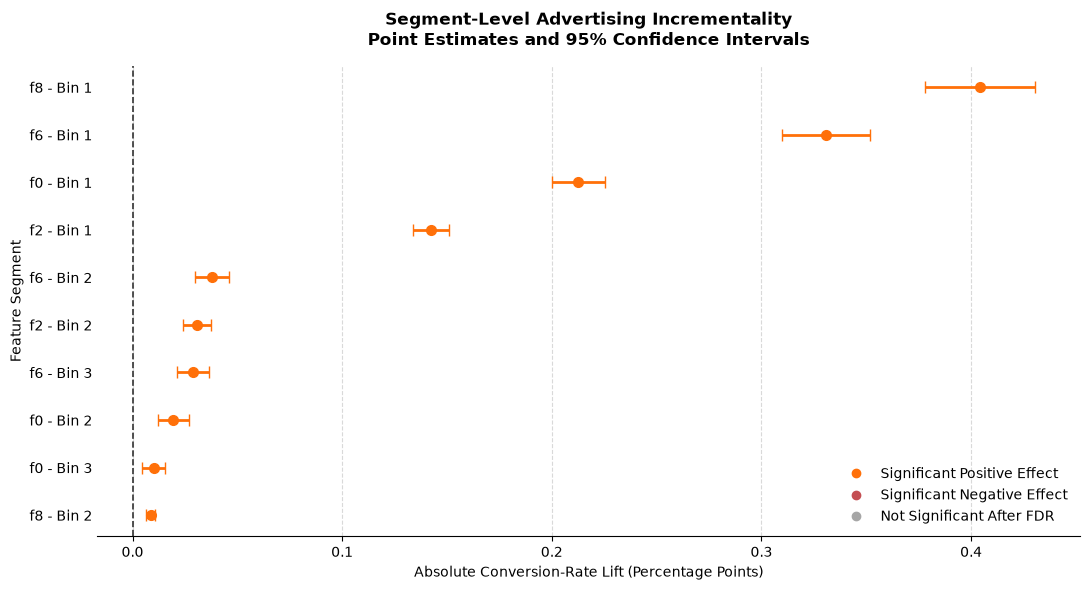

Figure saved to: ../outputs/figures/segment_conversion_lift.png


In [28]:
plot_data = (
    segment_results_summary
    .sort_values("absolute_lift_percentage_points")
    .reset_index(drop=True)
    .copy()
)

plot_data["lower_error"] = (
    plot_data["absolute_lift_percentage_points"]
    - plot_data["ci_lower_percentage_points"]
)
plot_data["upper_error"] = (
    plot_data["ci_upper_percentage_points"]
    - plot_data["absolute_lift_percentage_points"]
)

SIGNIFICANT_POSITIVE_COLOR = "#FF7009"
SIGNIFICANT_NEGATIVE_COLOR = "#C44E52"
NOT_SIGNIFICANT_COLOR = "#A6A6A6"
ZERO_LINE_COLOR = "#333333"
GRID_COLOR = "#D9D9D9"

plot_data["plot_color"] = np.select(
    [
        plot_data["significant_after_fdr"]
        & (plot_data["absolute_lift"] > 0),
        plot_data["significant_after_fdr"]
        & (plot_data["absolute_lift"] < 0),
    ],
    [SIGNIFICANT_POSITIVE_COLOR, SIGNIFICANT_NEGATIVE_COLOR],
    default=NOT_SIGNIFICANT_COLOR,
)

fig, ax = plt.subplots(
    figsize=(11, max(6, len(plot_data) * 0.45))
)
y_positions = np.arange(len(plot_data))

for position, row in plot_data.iterrows():
    ax.errorbar(
        row["absolute_lift_percentage_points"],
        position,
        xerr=np.array([[
            row["lower_error"]
        ], [
            row["upper_error"]
        ]]),
        fmt="o",
        color=row["plot_color"],
        ecolor=row["plot_color"],
        markersize=7,
        elinewidth=2,
        capsize=4,
    )

ax.axvline(0, color=ZERO_LINE_COLOR, linestyle="--", linewidth=1.2)
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_data["segment_label"])
ax.set_xlabel("Absolute Conversion-Rate Lift (Percentage Points)")
ax.set_ylabel("Feature Segment")
ax.set_title(
    "Segment-Level Advertising Incrementality\n"
    "Point Estimates and 95% Confidence Intervals",
    fontweight="bold",
    pad=15,
)
ax.xaxis.grid(True, color=GRID_COLOR, linestyle="--", linewidth=0.8)
ax.yaxis.grid(False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)

from matplotlib.lines import Line2D

legend_items = [
    Line2D([0], [0], marker="o", color=SIGNIFICANT_POSITIVE_COLOR,
           label="Significant Positive Effect", linestyle="None"),
    Line2D([0], [0], marker="o", color=SIGNIFICANT_NEGATIVE_COLOR,
           label="Significant Negative Effect", linestyle="None"),
    Line2D([0], [0], marker="o", color=NOT_SIGNIFICANT_COLOR,
           label="Not Significant After FDR", linestyle="None"),
]
ax.legend(handles=legend_items, loc="best", frameon=False)

plt.tight_layout()

figure_path = Path("../outputs/figures/segment_conversion_lift.png")
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {figure_path}")


### **Visualization Interpretation**

Points to the right of zero indicate positive estimated effects. A confidence interval crossing zero indicates uncertainty consistent with no effect at the unadjusted 5% level, while chart colors reflect the FDR-adjusted segment tests. Gray does not prove no effect; it means the available evidence was insufficient after correction.


## **Exploratory Follow-Up Candidates**

For each feature with FDR-adjusted evidence of heterogeneity in treatment odds ratios, the code flags **only the bin with the largest observed absolute conversion-rate lift**, provided that its within-bin effect passes the FDR correction, its unadjusted 95% confidence interval lies above zero, and each randomized group has at least 10,000 observations.

The rank is descriptive: the Breslow–Day test does not establish that the selected bin's **absolute lift** is statistically greater than another bin's. These flags identify hypotheses for a new randomized experiment, not validated targeting rules. The 95% intervals shown here are not adjusted for the candidate-selection process.


In [29]:
minimum_group_size = 10_000

segment_results_summary["sufficient_sample_size"] = (
    (segment_results_summary["control_users"] >= minimum_group_size)
    & (segment_results_summary["treatment_users"] >= minimum_group_size)
)

positive_effect = (
    (segment_results_summary["absolute_lift"] > 0)
    & segment_results_summary["significant_after_fdr"]
    & (segment_results_summary["ci_lower"] > 0)
    & segment_results_summary["sufficient_sample_size"]
)

segment_results_summary["exploratory_followup_candidate"] = (
    positive_effect
    & segment_results_summary["heterogeneity_after_fdr"]
    & (segment_results_summary["lift_rank_within_feature"] == 1)
)

candidate_segments = (
    segment_results_summary.loc[
        segment_results_summary["exploratory_followup_candidate"],
        ["feature", "segment", "segment_label", "control_users",
         "treatment_users", "control_rate", "treatment_rate",
         "absolute_lift_percentage_points", "ci_lower_percentage_points",
         "ci_upper_percentage_points", "adjusted_p_value",
         "heterogeneity_adjusted_p_value"],
    ]
    .sort_values("absolute_lift_percentage_points", ascending=False)
    .reset_index(drop=True)
)

print(f"Exploratory follow-up candidates: {len(candidate_segments)}")
display(candidate_segments)


Exploratory follow-up candidates: 2


,feature,segment,segment_label,control_users,treatment_users,control_rate,treatment_rate,absolute_lift_percentage_points,ci_lower_percentage_points,ci_upper_percentage_points,adjusted_p_value,heterogeneity_adjusted_p_value
0,f6,Bin 1,f6 - Bin 1,520347,3102297,0.004708,0.008017,0.330889,0.309807,0.351971,0.000000,0.000000
1,f0,Bin 1,f0 - Bin 1,1040133,5949663,0.003421,0.005546,0.212565,0.199856,0.225274,0.000000,0.000196


### **Candidate Interpretation**

The flags identify the highest **observed** absolute-lift bin within each feature for which the odds-ratio homogeneity test found heterogeneity after FDR correction. The other bins may also have positive effects. Selection on the same data can exaggerate the apparent advantage of the flagged bins. No pairwise test of differences in absolute lift was conducted, and these bins should be validated in a new randomized experiment before changing targeting.


## **Key Findings**

- Four anonymized features (`f0`, `f2`, `f6`, and `f8`) yielded at least two quantile-based bins, creating 10 segment comparisons.
- All 10 bins had positive treatment-minus-control conversion-rate estimates and passed the Benjamini–Hochberg correction for their **within-bin** tests at FDR 0.05. This alone does not establish different effects between bins.
- The Breslow–Day tests found evidence that treatment odds ratios vary across bins of `f0` and `f6` after correcting the four feature-level tests. They did not find sufficient evidence for `f2` or `f8`.
- `f6 - Bin 1` had the highest observed absolute lift within `f6` (about **0.331 percentage points**), and `f0 - Bin 1` within `f0` (about **0.213 percentage points**). They are exploratory follow-up candidates, not bins proven to outperform their peers in absolute lift.
- `f8 - Bin 1` had the largest absolute lift across the displayed bins (about **0.404 percentage points**), but `f8` did not pass the feature-level heterogeneity test. Its positive effect alone does not justify choosing it over `f8 - Bin 2` for targeting.
- These features are anonymized, and bins from different features overlap; estimated incremental conversions must not be summed across features.


## **Business Recommendations**

1. Use the overall randomized intention-to-treat result to evaluate whether assignment to the advertising strategy improves conversion.
2. Use the flagged `f0 - Bin 1` and `f6 - Bin 1` groups as exploratory hypotheses for a preregistered randomized follow-up experiment, after mapping the anonymized features to available audience definitions.
3. Test whether a proposed targeting policy outperforms broad assignment on the **absolute conversion-rate and economic scales**; the current Breslow–Day result tests odds-ratio heterogeneity and does not establish a deployable rule.
4. Obtain campaign costs and conversion value before estimating ROI or changing spend, and retain a randomized control group for future measurement.


## **Limitations**

- **Anonymized features:** The bins cannot be interpreted as recognizable demographic or behavioral groups.
- **Exploratory selection:** Segments are constructed and ranked using the same experiment. The flagged candidates and their original intervals require independent validation.
- **Overlapping feature segments:** Observations appear in one bin for every retained feature; incremental conversions cannot be summed across features.
- **Multiple testing:** FDR correction controls the expected false discovery proportion under its assumptions, but does not prove every selected effect is genuine. The reported 95% confidence intervals are unadjusted.
- **Different effect scales:** Breslow–Day evaluates treatment odds-ratio heterogeneity, whereas candidate ranking uses absolute conversion-rate differences. The test does not identify a winning bin or test pairwise absolute-lift differences.
- **Rare outcome:** Conversion is below 1%, so smaller segments have wider uncertainty.
- **Intention-to-treat estimate:** Assignment effects may be diluted because only a small proportion of treatment-assigned users were recorded as exposed.
- **No cost, conversion value, or time dimension:** ROI, profitability, trends, and long-term effects cannot be evaluated.
- **External validity:** Findings may not generalize beyond this experiment population and campaign setting.


## **Conclusion**

Advertising assignment shows positive estimated conversion effects within all 10 displayed bins. After adjustment across segment tests, each within-bin effect remains statistically significant. Feature-level tests find odds-ratio heterogeneity for `f0` and `f6`, while `f2` and `f8` do not show sufficient evidence of heterogeneity after correction.

`f0 - Bin 1` and `f6 - Bin 1` are flagged because each has the highest **observed** absolute lift within a feature with evidence of odds-ratio heterogeneity. This is a descriptive choice, not statistical proof that either bin has a larger absolute effect than other bins. A new randomized experiment with an operationally defined audience and a specified targeting comparison is needed before deployment. Costs and conversion value are needed to judge financial impact.


## **CSV Export**

Export the bin definitions, the complete segment results (including the exploratory candidate flag), and feature-level heterogeneity tests for Tableau. Numeric fields remain numeric. A separate candidate CSV is unnecessary because the flag can be filtered in the complete segment results table.


In [30]:
processed_data_path = Path("../data/processed")
processed_data_path.mkdir(parents=True, exist_ok=True)

segment_definitions_path = processed_data_path / "segment_definitions.csv"
segment_results_path = processed_data_path / "segment_results_summary.csv"
heterogeneity_results_path = processed_data_path / "feature_heterogeneity_results.csv"

segment_definitions.to_csv(segment_definitions_path, index=False)
segment_results_summary.to_csv(segment_results_path, index=False)
heterogeneity_results.to_csv(heterogeneity_results_path, index=False)

print("Exported files:")
for export_path in [
    segment_definitions_path,
    segment_results_path,
    heterogeneity_results_path,
]:
    print(f"- {export_path}")

print(
    "If a previous high_lift_segment_candidates.csv exists, "
    "remove it manually; this notebook no longer writes it."
)


Exported files:
- ../data/processed/segment_definitions.csv
- ../data/processed/segment_results_summary.csv
- ../data/processed/feature_heterogeneity_results.csv
If a previous high_lift_segment_candidates.csv exists, remove it manually; this notebook no longer writes it.
